# model training — MLP vs GCN vs GAT

In [1]:
%pip install rdkit


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import matplotlib.pyplot as plt

from dataset.dataset_util import load_esol, split_dataset, make_loaders, get_fingerprints, rmse, mae
from gnns.gnn_util import GCNModel, GATModel, run_training, get_predictions
from nn.nn_util import MLPModel, run_training_mlp, get_predictions_mlp

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## data

In [3]:
dataset = load_esol(root='data/')
train_set, val_set, test_set = split_dataset(dataset, seed=42)

# graph loaders for GCN/GAT
train_loader, val_loader, test_loader = make_loaders(train_set, val_set, test_set, batch_size=64)

# fingerprints for MLP
X_train, y_train = get_fingerprints(train_set)
X_val, y_val = get_fingerprints(val_set)
X_test, y_test = get_fingerprints(test_set)

print(f'train: {len(train_set)}  val: {len(val_set)}  test: {len(test_set)}')

[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerat

train: 902  val: 112  test: 114


[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerator
[13:06:11] DEPRECATION WARNING: please use MorganGenerat

## train MLP

In [4]:
mlp = MLPModel(in_features=1024, hidden=128)
print('training MLP...')
mlp_history = run_training_mlp(mlp, X_train, y_train, X_val, y_val, epochs=200, lr=0.001)

training MLP...
  epoch   1  train 11.2241  val 7.6036
  epoch  20  train 0.1685  val 1.3388
  epoch  40  train 0.0938  val 1.4044
  epoch  60  train 0.0912  val 1.3769
  epoch  80  train 0.0899  val 1.3729
  epoch 100  train 0.0943  val 1.3116
  epoch 120  train 0.0911  val 1.3159
  epoch 140  train 0.0888  val 1.3244
  epoch 160  train 0.1016  val 1.3264
  epoch 180  train 0.1022  val 1.3002
  epoch 200  train 0.0897  val 1.2998


## train GCN

In [5]:
gcn = GCNModel(in_channels=dataset.num_node_features, hidden=128)
print('training GCN...')
gcn_history = run_training(gcn, train_loader, val_loader, epochs=200, lr=0.001)

training GCN...
  epoch   1  train 5.9537  val 5.6557
  epoch  20  train 3.7504  val 4.2138
  epoch  40  train 3.2340  val 3.5566
  epoch  60  train 2.7568  val 3.3737
  epoch  80  train 2.5800  val 2.8566
  epoch 100  train 2.0528  val 2.2802
  epoch 120  train 1.7568  val 2.0506
  epoch 140  train 1.6029  val 1.8556
  epoch 160  train 1.4952  val 1.8215
  epoch 180  train 1.5390  val 1.8652
  epoch 200  train 1.4354  val 1.9389


## train GAT

In [6]:
gat = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
print('training GAT...')
gat_history = run_training(gat, train_loader, val_loader, epochs=200, lr=0.001)

training GAT...
  epoch   1  train 7.2992  val 5.0307
  epoch  20  train 3.0280  val 3.5375
  epoch  40  train 2.1176  val 2.3601
  epoch  60  train 1.5342  val 1.8732
  epoch  80  train 1.2415  val 1.7368
  epoch 100  train 1.0267  val 1.5332
  epoch 120  train 1.0351  val 1.3790
  epoch 140  train 0.8603  val 1.3313
  epoch 160  train 0.8092  val 1.2276
  epoch 180  train 0.7662  val 1.2809
  epoch 200  train 0.7207  val 1.1526


## test evaluation

In [7]:
# MLP predictions
mlp_preds = get_predictions_mlp(mlp, X_test)
mlp_rmse = rmse(mlp_preds.squeeze(), y_test.squeeze())
mlp_mae = mae(mlp_preds.squeeze(), y_test.squeeze())

# GCN predictions
gcn_preds, gcn_targets = get_predictions(gcn, test_loader)
gcn_rmse = rmse(gcn_preds, gcn_targets)
gcn_mae = mae(gcn_preds, gcn_targets)

# GAT predictions
gat_preds, gat_targets = get_predictions(gat, test_loader)
gat_rmse = rmse(gat_preds, gat_targets)
gat_mae = mae(gat_preds, gat_targets)

print(f'{"model":<8s}  {"RMSE":>8s}  {"MAE":>8s}')
print(f'{"-"*28}')
print(f'{"MLP":<8s}  {mlp_rmse:8.4f}  {mlp_mae:8.4f}')
print(f'{"GCN":<8s}  {gcn_rmse:8.4f}  {gcn_mae:8.4f}')
print(f'{"GAT":<8s}  {gat_rmse:8.4f}  {gat_mae:8.4f}')

model         RMSE       MAE
----------------------------
MLP         1.0786    0.8437
GCN         1.1550    0.9379
GAT         0.8668    0.6609


## loss curves

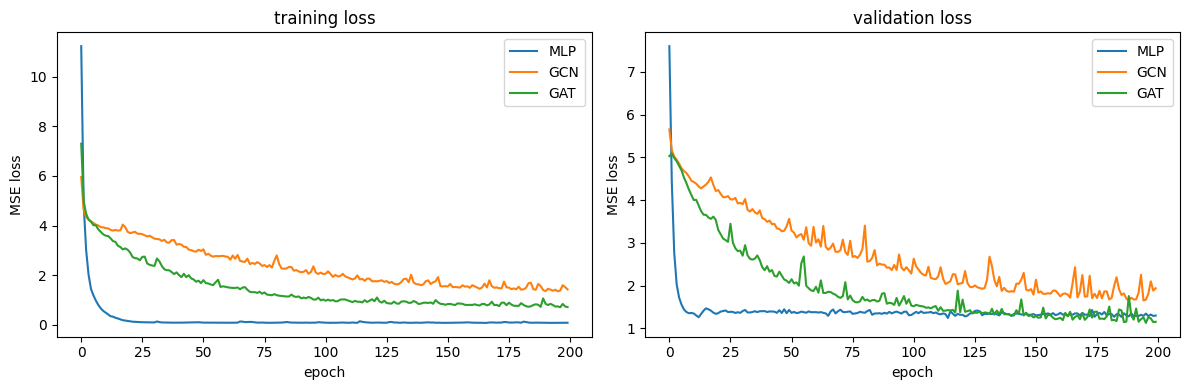

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# train loss
ax1.plot(mlp_history['train_loss'], label='MLP')
ax1.plot(gcn_history['train_loss'], label='GCN')
ax1.plot(gat_history['train_loss'], label='GAT')
ax1.set_xlabel('epoch')
ax1.set_ylabel('MSE loss')
ax1.set_title('training loss')
ax1.legend()

# val loss
ax2.plot(mlp_history['val_loss'], label='MLP')
ax2.plot(gcn_history['val_loss'], label='GCN')
ax2.plot(gat_history['val_loss'], label='GAT')
ax2.set_xlabel('epoch')
ax2.set_ylabel('MSE loss')
ax2.set_title('validation loss')
ax2.legend()

plt.tight_layout()
plt.show()

## predicted vs actual

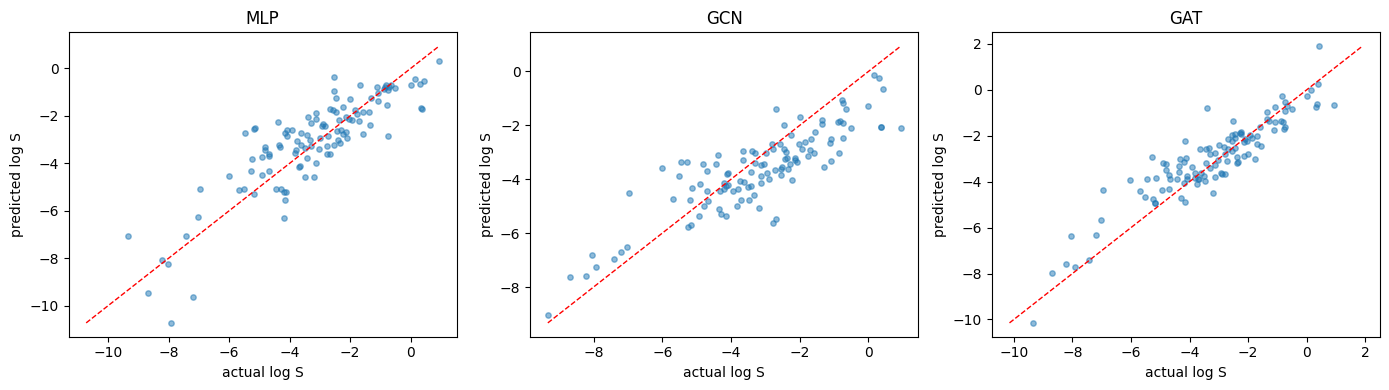

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

all_preds = [
    (mlp_preds.squeeze().detach().numpy(), y_test.squeeze().numpy(), 'MLP'),
    (gcn_preds.detach().numpy(), gcn_targets.detach().numpy(), 'GCN'),
    (gat_preds.detach().numpy(), gat_targets.detach().numpy(), 'GAT'),
]

for ax, (p, t, name) in zip(axes, all_preds):
    ax.scatter(t, p, alpha=0.5, s=15)
    # diagonal line
    lo = min(t.min(), p.min())
    hi = max(t.max(), p.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1)
    ax.set_xlabel('actual log S')
    ax.set_ylabel('predicted log S')
    ax.set_title(name)

plt.tight_layout()
plt.show()